<a href="https://colab.research.google.com/github/seo104/26-2-ESAA/blob/main/%EB%AF%B8%EB%8B%88%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#영화 관객수 데이터 EDA
데이터 : DACON 영화 관객수 예측(movies_train.csv)

목표 : 영화의 여러 변수들을 확인하여 관객수와 관련성이 높은 변수 발견

##데이터 확인

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.font_manager as fm
# 설치된 한글 폰트를 직접 지정한다
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
# seaborn 스타일이 폰트를 덮어쓰므로 set_style 뒤에 한글 폰트를 지정한다
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

df=pd.read_csv('movies_train.csv')
df.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


In [158]:
df.shape

(600, 12)

In [159]:
df.describe()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,2.700000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,1.050443e+06,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.791408e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,2.038000e+04,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,4.784236e+05,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,1.286569e+06,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


총 600개의 영화 데이터로 구성.

영화 제목, 배급사, 장르, 개봉일, 상영시간, 상영등급, 감독, 감독의 이전 작품 평균 관객수, 감독의 이전 작품 편수, 스태프 수, 주연배우 수, 관객수의 변수로 이루어져있음.

관객수는 평균과 중앙값의 차이가 커 일부 영화에 관객수가 집중되어 있음을 확인할 수 있음.

##결측치 확인

In [160]:
df.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


dir_prev_bfnum에서만 결측치 존재.

이전 작품이 없는 감독의 경우 나타나는 것으로 볼 수 있으므로 0으로 처리.

In [161]:
df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)

##변수 전처리
###개봉일 날짜 형식 변환
문자열로 나타나있는 날짜를 날짜 형식으로 변환

In [162]:
df['release_time'] = pd.to_datetime(df['release_time'])
df['release_year'] = df['release_time'].dt.year
df['release_month'] = df['release_time'].dt.month

###제작 규모 변수 생성
영화의 제작 규모를 구간으로 나눠 확인

In [163]:
df['scale'] = pd.cut(
    df['num_staff'], [-1, 0, 20, 80, 200, 400, 900], labels=['0명', '1-20', '21-80', '81-200', '201-400', '401+']
)

###관객수 분포 확인

관객수 왜도: 4.33


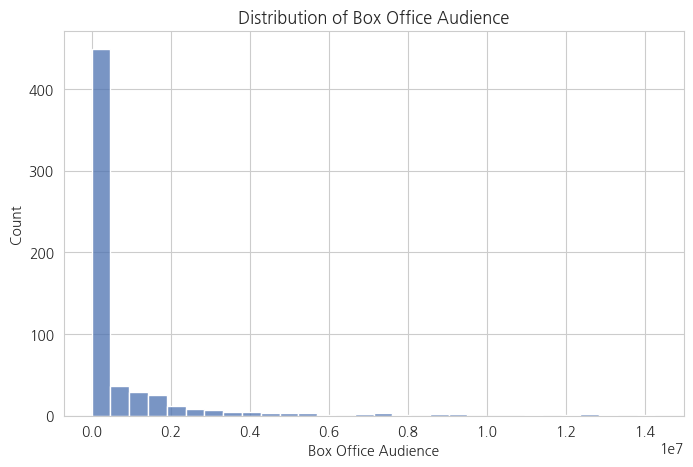

In [164]:
print('관객수 왜도:', round(df['box_off_num'].skew(), 2))

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='box_off_num',
    bins=30
)
plt.title('Distribution of Box Office Audience')
plt.xlabel('Box Office Audience')
plt.ylabel('Count')
plt.show()

관객수가 오른쪽으로 크게 치우쳐져있어서 로그 변환이 필요

In [165]:
df['log_box_off_num'] = np.log10(df['box_off_num'])

로그 변환 전과 후의 왜도 비교

변환 전 왜도: 4.33
변환 후 왜도: 0.12


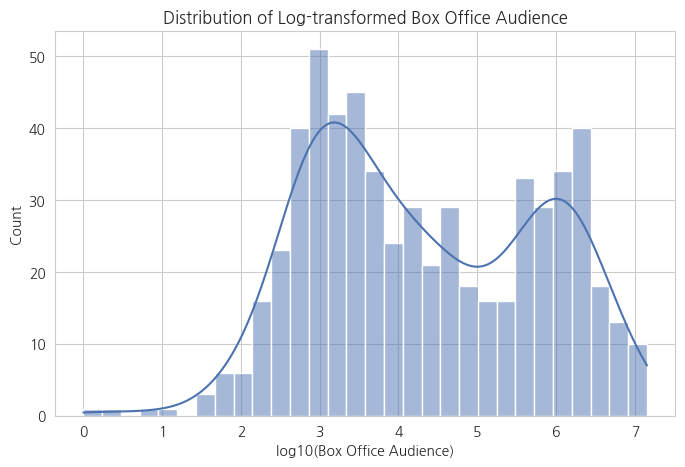

In [166]:
print('변환 전 왜도:', round(df['box_off_num'].skew(), 2))
print('변환 후 왜도:', round(df['log_box_off_num'].skew(), 2))

plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='log_box_off_num',
    bins=30,
    kde=True
)
plt.title('Distribution of Log-transformed Box Office Audience')
plt.xlabel('log10(Box Office Audience)')
plt.ylabel('Count')
plt.show()

##수치형 변수와 관객수의 상관관계

In [167]:
numeric_cols = [
    'time',
    'dir_prev_bfnum',
    'dir_prev_num',
    'num_staff',
    'num_actor',
    'box_off_num'
]
corr = df[numeric_cols].corr()
corr['box_off_num'].sort_values(ascending=False)

,box_off_num
box_off_num,1.000000
num_staff,0.544265
time,0.441452
dir_prev_bfnum,0.293791
dir_prev_num,0.259674
num_actor,0.111179


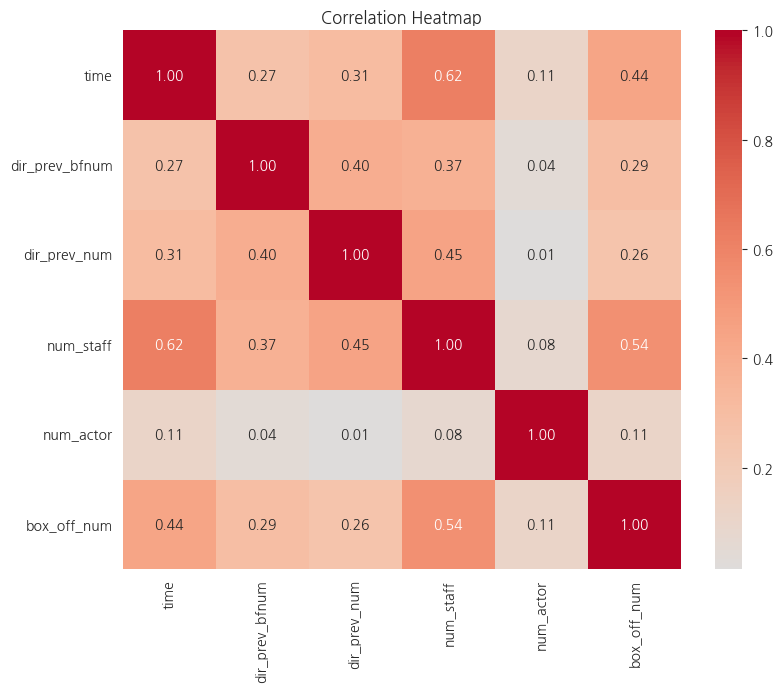

In [168]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Heatmap')
plt.show()

관객수와 가장 높은 상관관계를 보이는 변수는 스태프 수라는 것을 알 수 있음.

반면, 주연배우의 수는 관객수와의 상관관계가 낮게 나타남을 확인할 수 있음.

###상영시간과 관객수
숫자형 -> 숫자형 관계임으로 산점도로 확인.

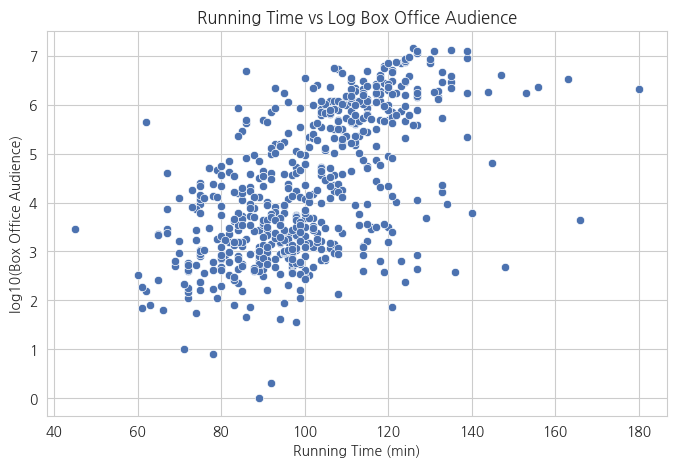

In [169]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='time',
    y='log_box_off_num'
)
plt.title('Running Time vs Log Box Office Audience')
plt.xlabel('Running Time (min)')
plt.ylabel('log10(Box Office Audience)')
plt.show()

상영시간이 길어질수록 관객수가 증가하는 양의 관계가 어느 정도 나타남.

상관관계 분석에서도 time은 관객수와 약 0.44의 양의 상관관계를 보여, 비교적 높은 관련성을 보임.

따라서 상영시간 역시 관객수와 관련된 주요 변수로 볼 수 있음.

###이전 작품 수와 관객수
작품의 수는 이산적인 그룹으로 나뉘기 때문에 이전 작품 수 별로 그룹화하여 박스플롯으로 관계성 확인.

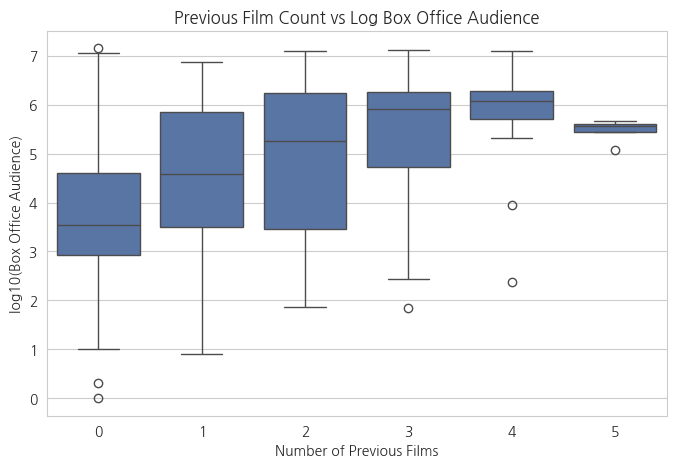

In [170]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='dir_prev_num',
    y='log_box_off_num'
)
plt.title('Previous Film Count vs Log Box Office Audience')
plt.xlabel('Number of Previous Films')
plt.ylabel('log10(Box Office Audience)')
plt.show()

이전 작품 수가 많은 감독의 영화일수록 관객수가 높은 경향을 확인할 수 있음.

즉, 감독의 경력이 많을수록 관객수도 높아지는 관계가 나타날 수 있음.

다만 상관히트맵을 보면 감독의 이전 작품 수와 스태프의 수가 양의 상관관계를 가지고 있음을 알 수 있기 때문에, 이 결과만으로 감독 경력이 관객수를 직접 증가시킨다고 해석하기엔 어려움이 있음.

###스태프 수와 관객수의 관계
스태프의 수를 구간으로 나누어 전처리를 해두었기 때문에 그 구간에 따라서 박스플롯을 그려 상관성 확인.

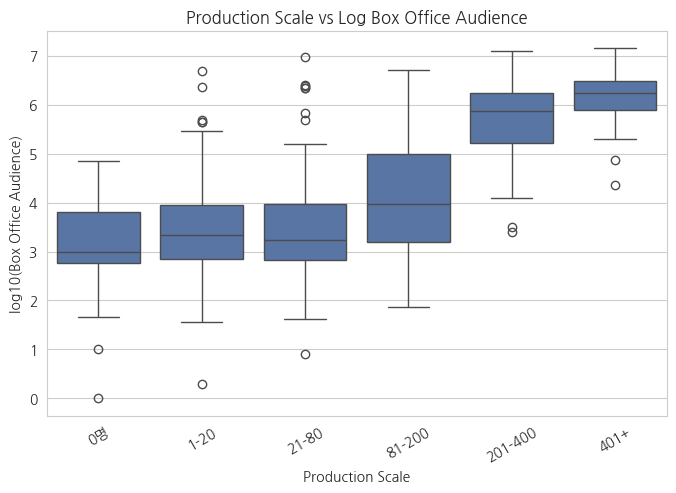

In [171]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='scale',
    y='log_box_off_num'
)
plt.title('Production Scale vs Log Box Office Audience')
plt.xlabel('Production Scale')
plt.ylabel('log10(Box Office Audience)')
plt.xticks(rotation=30)
plt.show()

###이전 작품 관객수와 현재 관객수
이전 작품이 없는 감독의 작품은 제외한 데이터만 가지고 분석.

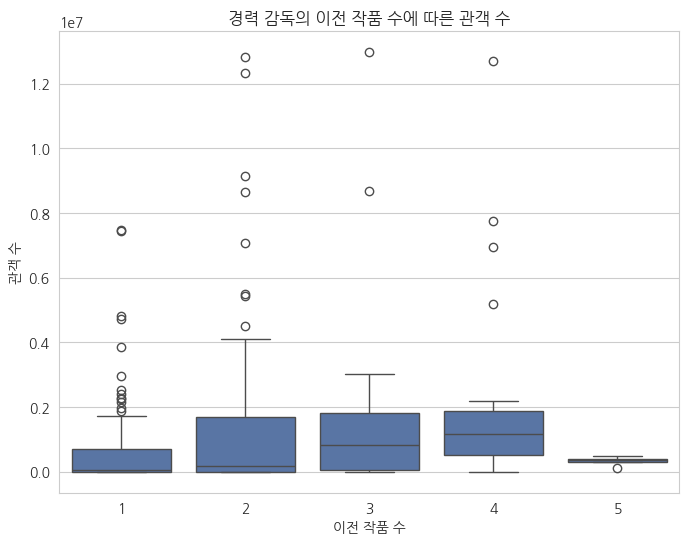

In [172]:
df_career = df[df['dir_prev_num'] > 0]
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='dir_prev_num',
    y='box_off_num',
    data=df_career
)
plt.xlabel('이전 작품 수')
plt.ylabel('관객 수')
plt.title('경력 감독의 이전 작품 수에 따른 관객 수')
plt.show()